#  Autonomous Navigation Drone
### Multimodel System for Sequence Learning Navigation + Drone Info Analyzer

**Navigation System:** Sequence of frames → Direction (Left / Right / Straight / Stop)  
**Drone Info System:** Drone image → Type, Speed Category, Price Range

##  Install Dependencies (Colab)

In [3]:
!pip install -q yt-dlp
!pip install -q beautifulsoup4
!apt-get -qq install -y ffmpeg
import subprocess
subprocess.run('ffmpeg -version', shell=True)

!pip install opencv-python-headless

##  Data Collection - Scraping Video from YouTube

In [4]:
from bs4 import BeautifulSoup
import requests
import os
import subprocess

video_url = "https://youtu.be/GTifvVZBNWs"

# Remove old video if exists
if os.path.exists("video.mp4"):
    os.remove("video.mp4")

# Download with yt-dlp
subprocess.run(f'yt-dlp -f "bestvideo[ext=mp4]+bestaudio[ext=m4a]/best[ext=mp4]/best" --merge-output-format mp4 -o "video.mp4" {video_url}', shell=True)
if not os.path.exists("video.mp4") or os.path.getsize("video.mp4") == 0:
    raise Exception("download failed!")

print(f"✅ Downloaded successfully! Size: {os.path.getsize('video.mp4') / 1024 / 1024:.1f} MB")

✅ Downloaded successfully! Size: 19.9 MB


In [5]:
import cv2
import os
import shutil
import subprocess

# Clear old frames
if os.path.exists("frames"):
    shutil.rmtree("frames")
os.makedirs("frames", exist_ok=True)

# Try OpenCV first
video = cv2.VideoCapture("video.mp4")
fps = video.get(cv2.CAP_PROP_FPS)
total = int(video.get(cv2.CAP_PROP_FRAME_COUNT))
print(f"Video info: FPS={fps}, Total frames={total}")

count = 0
while True:
    success, frame = video.read()
    if not success:
        break
    cv2.imwrite(f"frames/frame_{count}.jpg", frame)
    count += 1

video.release()

# If OpenCV failed, use ffmpeg directly
if count == 0:
    print("⚠️ OpenCV couldn't read video. Using ffmpeg...")
    subprocess.run('ffmpeg -i video.mp4 -q:v 2 frames/frame_%d.jpg -hide_banner -loglevel error', shell=True)
    count = len([f for f in os.listdir("frames") if f.endswith(".jpg")])

print(f"✅ Done extracting {count} frames")

if count == 0:
    raise Exception("Failed to extract frames! Check video file.")

Video info: FPS=29.97002997002997, Total frames=1747
⚠️ OpenCV couldn't read video. Using ffmpeg...
✅ Done extracting 1747 frames


##  Build Sequences & Labeling

In [6]:
import numpy as np
import cv2
import os

frames_path = "frames"

# Sort frames numerically (handles both frame_0.jpg and frame_1.jpg naming)
def sort_key(f):
    num = ''.join(filter(str.isdigit, f))
    return int(num) if num else 0

frames = sorted([f for f in os.listdir(frames_path) if f.endswith(".jpg")], key=sort_key)

print("Total frames:", len(frames))

if len(frames) < 5:
    raise ValueError("Not enough frames!")

sequence_length = 5
X = []
y = []

frame_skip = 2

for i in range(0, len(frames) - sequence_length, frame_skip):
    seq = []

    for j in range(sequence_length):
        img_path = os.path.join(frames_path, frames[i + j])
        img = cv2.imread(img_path)

        if img is None:
            continue

        img = cv2.resize(img, (224, 224))
        img = img / 255.0

        seq.append(img)

    if len(seq) == sequence_length:
        X.append(seq)

        last_frame = seq[-1]
        gray = cv2.cvtColor((last_frame * 255).astype(np.uint8), cv2.COLOR_BGR2GRAY)

        h, w = gray.shape

        left = gray[:, :w//2].mean()
        right = gray[:, w//2:].mean()
        overall = gray.mean()

        threshold = 5

        if overall < 40:
            label = 3  # Stop
        elif abs(left - right) < threshold:
            label = 2  # Straight
        elif left < right:
            label = 1  # Right
        else:
            label = 0  # Left

        y.append(label)


X = np.array(X, dtype="float32")
y = np.array(y)

print("X shape:", X.shape)
print("y shape:", y.shape)

unique, counts = np.unique(y, return_counts=True)

print("\nClass distribution:")
for u, c in zip(unique, counts):
    print(f"Class {u}: {c}")

MAX_SAMPLES = 800

X = X[:MAX_SAMPLES]
y = y[:MAX_SAMPLES]

print("\nAfter sampling:")
print("X shape:", X.shape)
print("y shape:", y.shape)

np.save("X.npy", X)
np.save("y.npy", y)

print("\n✅ Dataset saved!")

Total frames: 1747
X shape: (871, 5, 224, 224, 3)
y shape: (871,)

Class distribution:
Class 0: 349
Class 1: 214
Class 2: 89
Class 3: 219

After sampling:
X shape: (800, 5, 224, 224, 3)
y shape: (800,)

✅ Dataset saved!


##  Drone Info Scraping (Wikipedia UAV Dataset)

In [7]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import time

base_url = "https://en.wikipedia.org/wiki/List_of_unmanned_aerial_vehicles"
headers = {"User-Agent": "Mozilla/5.0"}


r = requests.get(base_url, headers=headers)
soup = BeautifulSoup(r.text, "html.parser")

links = []
for a in soup.find_all("a", href=True):
    href = a["href"]
    if href.startswith("/wiki/") and ":" not in href and "Main_Page" not in href:
        full = "https://en.wikipedia.org" + href
        links.append(full)

links = list(set(links))
print(f"Total potential links: {len(links)}")

dataset = []
drone_keywords = ['uav', 'unmanned', 'drone', 'aerial', 'aircraft', 'quadcopter', 'helicopter', 'missile', 'loitering']

for link in links:
    if len(dataset) >= 100:
        break

    try:
        r = requests.get(link, headers=headers, timeout=10)
        soup = BeautifulSoup(r.text, "html.parser")

        title = soup.find("h1")
        if not title: continue
        name = title.text.strip()

        if any(k in name for k in ["List of", "Category", "Help", "Portal", "Wikipedia"]):
            continue

        infobox = soup.find("table", {"class": "infobox"})
        if not infobox: continue

        specs = {}
        for row in infobox.find_all("tr"):
            th = row.find("th")
            td = row.find("td")
            if th and td:
                specs[th.text.strip()] = td.text.strip()

        drone_type = str(specs.get('Type', '')).lower()
        intro_text = soup.find("p").text.lower() if soup.find("p") else ""

        is_real_drone = any(word in drone_type for word in drone_keywords) or \
                       any(word in intro_text for word in drone_keywords)

        if not is_real_drone:
            continue

        img = None
        img_tag = infobox.find("img")
        if img_tag:
            img = "https:" + img_tag["src"] if img_tag["src"].startswith("//") else img_tag["src"]

        if img and len(specs) > 2:
            dataset.append({
                "name": name,
                "image": img,
                "specs": specs,
                "source": link
            })
            print(f"✅ Collected [{len(dataset)}]: {name}")

        time.sleep(0.3)

    except Exception as e:
        continue


df = pd.DataFrame(dataset)
df.to_csv("UAV_Premium_Dataset.csv", index=False)

print(f"\n🚀 Mission Accomplished!")
print(f"Final Clean Dataset: {df.shape}")

Total potential links: 899
✅ Collected [1]: Interstate TDR
✅ Collected [2]: Naval Research Laboratory Flyrt
✅ Collected [3]: Tupolev Tu-123
✅ Collected [4]: Anduril YFQ-44
✅ Collected [5]: Selex ES Falco
✅ Collected [6]: Elbit Hermes 450
✅ Collected [7]: Hydra Technologies Gavilán
✅ Collected [8]: Baykar Bayraktar KALKAN
✅ Collected [9]: Beechcraft AQM-37 Jayhawk
✅ Collected [10]: Aeroscout Scout B1-100
✅ Collected [11]: FMA IA-59
✅ Collected [12]: Fieseler Fi 157
✅ Collected [13]: BETA UAS
✅ Collected [14]: Elbit Hermes 900
✅ Collected [15]: Baykar Bayraktar Akinci
✅ Collected [16]: Alenia Aermacchi Sky-Y
✅ Collected [17]: NCSIST Chien Hsiang
✅ Collected [18]: BAE Systems Demon
✅ Collected [19]: Shahed 191
✅ Collected [20]: Bayraktar Mini
✅ Collected [21]: Radioplane Q-1
✅ Collected [22]: Beechcraft AQM-37 Jayhawk
✅ Collected [23]: Nord Aviation CT20
✅ Collected [24]: IAI Eitan
✅ Collected [25]: WB Electronics Warmate
✅ Collected [26]: Ryan Firebee
✅ Collected [27]: General Atomics Al

In [8]:
print(f"Dataset shape: {df.shape}")
df.head(10)

Dataset shape: (100, 4)


,name,image,specs,source
0,Interstate TDR,https://upload.wikimedia.org/wikipedia/commons...,"{'Type': 'Assault drone', 'National origin': '...",https://en.wikipedia.org/wiki/Interstate_TDR
1,Naval Research Laboratory Flyrt,https://upload.wikimedia.org/wikipedia/commons...,"{'Type': 'Radar decoy drone', 'National origin...",https://en.wikipedia.org/wiki/Naval_Research_L...
2,Tupolev Tu-123,https://upload.wikimedia.org/wikipedia/commons...,"{'Type': 'Reconnaissance Drone', 'National ori...",https://en.wikipedia.org/wiki/Tupolev_Tu-123
3,Anduril YFQ-44,https://upload.wikimedia.org/wikipedia/commons...,{'Type': 'Unmanned combat aerial vehicle colla...,https://en.wikipedia.org/wiki/Anduril_YFQ-44
4,Selex ES Falco,https://upload.wikimedia.org/wikipedia/commons...,{'Type': 'Falco and Falco EVO: Unmanned surve...,https://en.wikipedia.org/wiki/Falco_UAV
5,Elbit Hermes 450,https://upload.wikimedia.org/wikipedia/commons...,{'Type': 'Unmanned surveillance and reconnaiss...,https://en.wikipedia.org/wiki/Elbit_Hermes_450
6,Hydra Technologies Gavilán,https://upload.wikimedia.org/wikipedia/commons...,"{'Type': 'Unmanned aerial vehicle', 'Manufactu...",https://en.wikipedia.org/wiki/Hydra_Technologi...
7,Baykar Bayraktar KALKAN,https://upload.wikimedia.org/wikipedia/commons...,{'Type': 'VTOL unmanned surveillance and recon...,https://en.wikipedia.org/wiki/Bayraktar_VTOL
8,Beechcraft AQM-37 Jayhawk,https://upload.wikimedia.org/wikipedia/commons...,"{'Type': 'Unmanned aerial vehicle drone', 'Man...",https://en.wikipedia.org/wiki/Beechcraft_Model...
9,Aeroscout Scout B1-100,https://upload.wikimedia.org/wikipedia/commons...,{'Type': 'Autonomous unmanned helicopter drone...,https://en.wikipedia.org/wiki/Aeroscout_Scout_...


---
##  Load Data & Preprocessing for Navigation Models

In [9]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from tensorflow.keras import layers, Model
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

# Load saved data
X = np.load("X.npy")
y = np.load("y.npy")

print(f"X shape: {X.shape}")  # (samples, seq_len, 224, 224, 3)
print(f"y shape: {y.shape}")
print(f"Classes: {np.unique(y)}")

# One-hot encode labels
num_classes = 4
y_cat = to_categorical(y, num_classes=num_classes)

# Train/Test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y_cat, test_size=0.2, random_state=42, stratify=y
)

print(f"\nTrain: {X_train.shape[0]} samples")
print(f"Test: {X_test.shape[0]} samples")

class_names = ['Left', 'Right', 'Straight', 'Stop']

X shape: (800, 5, 224, 224, 3)
y shape: (800,)
Classes: [0 1 2 3]

Train: 640 samples
Test: 160 samples


###  Model 1: CNN Only (Baseline)





In [10]:
# Model 1: CNN Only (uses last frame of each sequence)
def build_cnn_model(input_shape=(224, 224, 3), num_classes=4):
    inputs = layers.Input(shape=input_shape)
    x = layers.Conv2D(32, 3, activation='relu', padding='same')(inputs)
    x = layers.MaxPooling2D(2)(x)
    x = layers.Conv2D(64, 3, activation='relu', padding='same')(x)
    x = layers.MaxPooling2D(2)(x)
    x = layers.Conv2D(128, 3, activation='relu', padding='same')(x)
    x = layers.MaxPooling2D(2)(x)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    model = Model(inputs, outputs)
    return model

# Use only last frame for CNN baseline
X_train_cnn = X_train[:, -1]  # shape: (samples, 224, 224, 3)
X_test_cnn = X_test[:, -1]

model_cnn = build_cnn_model()
model_cnn.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model_cnn.summary()

history_cnn = model_cnn.fit(
    X_train_cnn, y_train,
    validation_data=(X_test_cnn, y_test),
    epochs=15, batch_size=16, verbose=1
)

cnn_acc = model_cnn.evaluate(X_test_cnn, y_test, verbose=0)[1]
print(f"\n✅ CNN Baseline Accuracy: {cnn_acc:.4f}")

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 110,276 (430.77 KB)

 Trainable params: 110,276 (430.77 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
40/40 ━━━━━━━━━━━━━━━━━━━━ 9s 62ms/step - accuracy: 0.3453 - loss: 1.3160 - val_accuracy: 0.4125 - val_loss: 1.2202
Epoch 2/15
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.5141 - loss: 1.0981 - val_accuracy: 0.5750 - val_loss: 0.9115
Epoch 3/15
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.5719 - loss: 0.9472 - val_accuracy: 0.5250 - val_loss: 0.8865
Epoch 4/15
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.5750 - loss: 0.8803 - val_accuracy: 0.5750 - val_loss: 0.8818
Epoch 5/15
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.5938 - loss: 0.8803 - val_accuracy: 0.6125 - val_loss: 0.8135
Epoch 6/15
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.5875 - loss: 0.8632 - val_accuracy: 0.6187 - val_loss: 0.8339
Epoch 7/15
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - accuracy: 0.5813 - loss: 0.8846 - val_accuracy: 0.5750 - val_loss: 0.8140
Epoch 8/15
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.6109 - loss: 0.8353 - val_accuracy: 0.5938 - v

## CNN Feature Extractor (Shared for Sequence Models)

In [11]:
# Extract CNN features from sequences using MobileNetV2 (lightweight for Colab)
from tensorflow.keras.applications import MobileNetV2

base_cnn = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224, 224, 3), pooling='avg')
base_cnn.trainable = False  # Freeze for feature extraction

print("Extracting features from training sequences...")
seq_len = X_train.shape[1]

# Extract features: (samples, seq_len, features)
def extract_features(X_data, model):
    n_samples = X_data.shape[0]
    seq_len = X_data.shape[1]
    features = []
    for i in range(n_samples):
        seq_features = model.predict(X_data[i], verbose=0)  # (seq_len, 1280)
        features.append(seq_features)
        if (i+1) % 50 == 0:
            print(f"  Processed {i+1}/{n_samples}")
    return np.array(features)

X_train_feat = extract_features(X_train, base_cnn)
X_test_feat = extract_features(X_test, base_cnn)

print(f"\nFeature shapes:")
print(f"  X_train_feat: {X_train_feat.shape}")  # (samples, seq_len, 1280)
print(f"  X_test_feat: {X_test_feat.shape}")

# Save features to avoid re-extraction
np.save("X_train_feat.npy", X_train_feat)
np.save("X_test_feat.npy", X_test_feat)
np.save("y_train.npy", y_train)
np.save("y_test.npy", y_test)
print("✅ Features saved!")

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Extracting features from training sequences...
  Processed 50/640
  Processed 100/640
  Processed 150/640
  Processed 200/640
  Processed 250/640
  Processed 300/640
  Processed 350/640
  Processed 400/640
  Processed 450/640
  Processed 500/640
  Processed 550/640
  Processed 600/640
  Processed 50/160
  Processed 100/160
  Processed 150/160

Feature shapes:
  X_train_feat: (640, 5, 1280)
  X_test_feat: (160, 5, 1280)
✅ Features saved!


##  Model 2: CNN + RNN (SimpleRNN)

In [12]:
# Model 2: CNN + SimpleRNN
def build_cnn_rnn(seq_len, feature_dim, num_classes=4):
    inputs = layers.Input(shape=(seq_len, feature_dim))
    x = layers.SimpleRNN(128, return_sequences=False)(inputs)
    x = layers.Dense(64, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    model = Model(inputs, outputs)
    return model

model_rnn = build_cnn_rnn(X_train_feat.shape[1], X_train_feat.shape[2])
model_rnn.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model_rnn.summary()

history_rnn = model_rnn.fit(
    X_train_feat, y_train,
    validation_data=(X_test_feat, y_test),
    epochs=20, batch_size=16, verbose=1
)

rnn_acc = model_rnn.evaluate(X_test_feat, y_test, verbose=0)[1]
print(f"\n✅ CNN + RNN Accuracy: {rnn_acc:.4f}")

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 5, 1280)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (None, 128)            │       180,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 188,868 (737.77 KB)

 Trainable params: 188,868 (737.77 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - accuracy: 0.4484 - loss: 1.2701 - val_accuracy: 0.6313 - val_loss: 1.0484
Epoch 2/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6562 - loss: 0.9246 - val_accuracy: 0.6875 - val_loss: 0.8881
Epoch 3/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7156 - loss: 0.7502 - val_accuracy: 0.7250 - val_loss: 0.7271
Epoch 4/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7844 - loss: 0.5922 - val_accuracy: 0.6875 - val_loss: 0.8209
Epoch 5/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8344 - loss: 0.4620 - val_accuracy: 0.7688 - val_loss: 0.6089
Epoch 6/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8453 - loss: 0.4207 - val_accuracy: 0.7812 - val_loss: 0.5888
Epoch 7/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8578 - loss: 0.4038 - val_accuracy: 0.7750 - val_loss: 0.6150
Epoch 8/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8719 - loss: 0.3563 - val_accuracy: 0.7563 - val_loss

##  Model 3: CNN + LSTM

In [13]:
# Model 3: CNN + LSTM
def build_cnn_lstm(seq_len, feature_dim, num_classes=4):
    inputs = layers.Input(shape=(seq_len, feature_dim))
    x = layers.LSTM(128, return_sequences=False)(inputs)
    x = layers.Dense(64, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    model = Model(inputs, outputs)
    return model

model_lstm = build_cnn_lstm(X_train_feat.shape[1], X_train_feat.shape[2])
model_lstm.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model_lstm.summary()

history_lstm = model_lstm.fit(
    X_train_feat, y_train,
    validation_data=(X_test_feat, y_test),
    epochs=20, batch_size=16, verbose=1
)

lstm_acc = model_lstm.evaluate(X_test_feat, y_test, verbose=0)[1]
print(f"\n✅ CNN + LSTM Accuracy: {lstm_acc:.4f}")

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 5, 1280)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 128)            │       721,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 729,924 (2.78 MB)

 Trainable params: 729,924 (2.78 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.5109 - loss: 1.1681 - val_accuracy: 0.6187 - val_loss: 0.9708
Epoch 2/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.6531 - loss: 0.9216 - val_accuracy: 0.6562 - val_loss: 0.8753
Epoch 3/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7328 - loss: 0.7514 - val_accuracy: 0.7563 - val_loss: 0.6780
Epoch 4/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.7812 - loss: 0.6085 - val_accuracy: 0.6687 - val_loss: 0.7840
Epoch 5/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.8094 - loss: 0.5388 - val_accuracy: 0.7188 - val_loss: 0.6548
Epoch 6/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.8516 - loss: 0.4399 - val_accuracy: 0.8125 - val_loss: 0.5553
Epoch 7/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.8844 - loss: 0.3536 - val_accuracy: 0.8125 - val_loss: 0.5537
Epoch 8/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.8922 - loss: 0.3172 - val_accuracy: 0.8250 - val

##  Model 4: CNN + GRU

In [14]:
# Model 4: CNN + GRU
def build_cnn_gru(seq_len, feature_dim, num_classes=4):
    inputs = layers.Input(shape=(seq_len, feature_dim))
    x = layers.GRU(128, return_sequences=False)(inputs)
    x = layers.Dense(64, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    model = Model(inputs, outputs)
    return model

model_gru = build_cnn_gru(X_train_feat.shape[1], X_train_feat.shape[2])
model_gru.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model_gru.summary()

history_gru = model_gru.fit(
    X_train_feat, y_train,
    validation_data=(X_test_feat, y_test),
    epochs=20, batch_size=16, verbose=1
)

gru_acc = model_gru.evaluate(X_test_feat, y_test, verbose=0)[1]
print(f"\n✅ CNN + GRU Accuracy: {gru_acc:.4f}")

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 5, 1280)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ (None, 128)            │       541,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 549,956 (2.10 MB)

 Trainable params: 549,956 (2.10 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.4656 - loss: 1.2667 - val_accuracy: 0.6562 - val_loss: 1.0230
Epoch 2/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6656 - loss: 0.8974 - val_accuracy: 0.6562 - val_loss: 0.8826
Epoch 3/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7437 - loss: 0.7283 - val_accuracy: 0.7625 - val_loss: 0.7169
Epoch 4/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7891 - loss: 0.5807 - val_accuracy: 0.7875 - val_loss: 0.6050
Epoch 5/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8578 - loss: 0.4393 - val_accuracy: 0.7875 - val_loss: 0.5800
Epoch 6/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8687 - loss: 0.3587 - val_accuracy: 0.7688 - val_loss: 0.6635
Epoch 7/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9047 - loss: 0.2790 - val_accuracy: 0.7937 - val_loss: 0.6171
Epoch 8/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.9250 - loss: 0.2406 - val_accuracy: 0.7375 - val_l

##  Model 5: CNN + Transformer

In [15]:
# Model 5: CNN + Transformer (Most Advanced)
class TransformerBlock(layers.Layer):
    def __init__(self, embed_dim, num_heads, ff_dim, rate=0.1):
        super().__init__()
        self.att = layers.MultiHeadAttention(num_heads=num_heads, key_dim=embed_dim)
        self.ffn = tf.keras.Sequential([
            layers.Dense(ff_dim, activation="relu"),
            layers.Dense(embed_dim),
        ])
        self.layernorm1 = layers.LayerNormalization(epsilon=1e-6)
        self.layernorm2 = layers.LayerNormalization(epsilon=1e-6)
        self.dropout1 = layers.Dropout(rate)
        self.dropout2 = layers.Dropout(rate)

    def call(self, inputs, training=False):
        attn_output = self.att(inputs, inputs)
        attn_output = self.dropout1(attn_output, training=training)
        out1 = self.layernorm1(inputs + attn_output)
        ffn_output = self.ffn(out1)
        ffn_output = self.dropout2(ffn_output, training=training)
        return self.layernorm2(out1 + ffn_output)


class PositionalEncoding(layers.Layer):
    def __init__(self, seq_len, embed_dim):
        super().__init__()
        self.pos_embedding = layers.Embedding(input_dim=seq_len, output_dim=embed_dim)
        self.seq_len = seq_len

    def call(self, x):
        positions = tf.range(start=0, limit=self.seq_len, delta=1)
        pos_embed = self.pos_embedding(positions)
        return x + pos_embed


def build_cnn_transformer(seq_len, feature_dim, num_classes=4, num_heads=4, ff_dim=256):
    inputs = layers.Input(shape=(seq_len, feature_dim))

    # Project features to smaller dimension for transformer
    x = layers.Dense(128)(inputs)

    # Positional encoding
    x = PositionalEncoding(seq_len, 128)(x)

    # Transformer blocks
    x = TransformerBlock(128, num_heads, ff_dim)(x)
    x = TransformerBlock(128, num_heads, ff_dim)(x)

    # Global average pooling over sequence
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dense(64, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    model = Model(inputs, outputs)
    return model

model_transformer = build_cnn_transformer(X_train_feat.shape[1], X_train_feat.shape[2])
model_transformer.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model_transformer.summary()

history_transformer = model_transformer.fit(
    X_train_feat, y_train,
    validation_data=(X_test_feat, y_test),
    epochs=25, batch_size=16, verbose=1
)

transformer_acc = model_transformer.evaluate(X_test_feat, y_test, verbose=0)[1]
print(f"\n CNN + Transformer Accuracy: {transformer_acc:.4f}")

Model: "functional_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 5, 1280)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 5, 128)         │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ positional_encoding             │ (None, 5, 128)         │           640 │
│ (PositionalEncoding)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block               │ (None, 5, 128)         │       330,240 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_1             │ (None, 5, 128)         │       330,240 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 833,604 (3.18 MB)

 Trainable params: 833,604 (3.18 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/25
40/40 ━━━━━━━━━━━━━━━━━━━━ 14s 36ms/step - accuracy: 0.3266 - loss: 1.4184 - val_accuracy: 0.4812 - val_loss: 1.2735
Epoch 2/25
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.4313 - loss: 1.2355 - val_accuracy: 0.4938 - val_loss: 1.1440
Epoch 3/25
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6328 - loss: 0.9826 - val_accuracy: 0.7312 - val_loss: 0.8112
Epoch 4/25
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7375 - loss: 0.7897 - val_accuracy: 0.6187 - val_loss: 0.9787
Epoch 5/25
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7656 - loss: 0.7140 - val_accuracy: 0.7063 - val_loss: 0.8211
Epoch 6/25
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7812 - loss: 0.6274 - val_accuracy: 0.7625 - val_loss: 0.6723
Epoch 7/25
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8203 - loss: 0.5496 - val_accuracy: 0.7563 - val_loss: 0.7630
Epoch 8/25
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7969 - loss: 0.5933 - val_accuracy: 0.7437 - val_l

---
##  Model Comparison

📊 MODEL COMPARISON - Navigation System
            Model  Accuracy %
       CNN + LSTM       84.38
        CNN + GRU       84.38
        CNN + RNN       80.00
CNN + Transformer       79.37
   CNN (Baseline)       73.75

🏆 Best Model: CNN + LSTM (84.38%)


/tmp/ipykernel_31908/2274040180.py:31: UserWarning: Glyph 128641 (\N{HELICOPTER}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_31908/2274040180.py:32: UserWarning: Glyph 128641 (\N{HELICOPTER}) missing from font(s) DejaVu Sans.
  plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128641 (\N{HELICOPTER}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


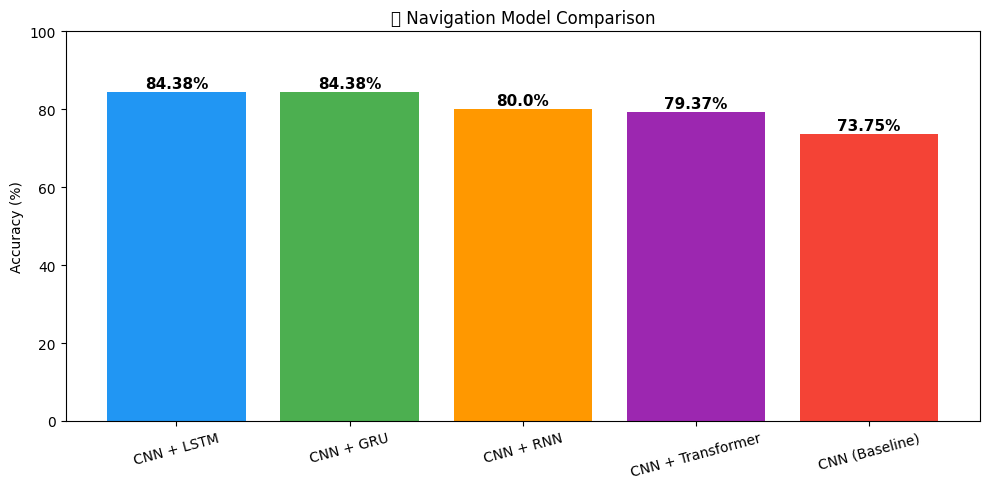

In [16]:
# ===== COMPARISON TABLE =====
import pandas as pd

results = {
    'Model': ['CNN (Baseline)', 'CNN + RNN', 'CNN + LSTM', 'CNN + GRU', 'CNN + Transformer'],
    'Accuracy': [cnn_acc, rnn_acc, lstm_acc, gru_acc, transformer_acc]
}

df_results = pd.DataFrame(results)
df_results['Accuracy %'] = (df_results['Accuracy'] * 100).round(2)
df_results = df_results.sort_values('Accuracy', ascending=False).reset_index(drop=True)

print("=" * 60)
print("📊 MODEL COMPARISON - Navigation System")
print("=" * 60)
print(df_results[['Model', 'Accuracy %']].to_string(index=False))
print("=" * 60)
print(f"\n🏆 Best Model: {df_results.iloc[0]['Model']} ({df_results.iloc[0]['Accuracy %']}%)")

# Bar chart
plt.figure(figsize=(10, 5))
colors = ['#2196F3', '#4CAF50', '#FF9800', '#9C27B0', '#F44336']
bars = plt.bar(df_results['Model'], df_results['Accuracy %'], color=colors)
plt.ylabel('Accuracy (%)')
plt.title('🚁 Navigation Model Comparison')
plt.ylim(0, 100)
for bar, val in zip(bars, df_results['Accuracy %']):
    plt.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 1,
             f'{val}%', ha='center', fontsize=11, fontweight='bold')
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

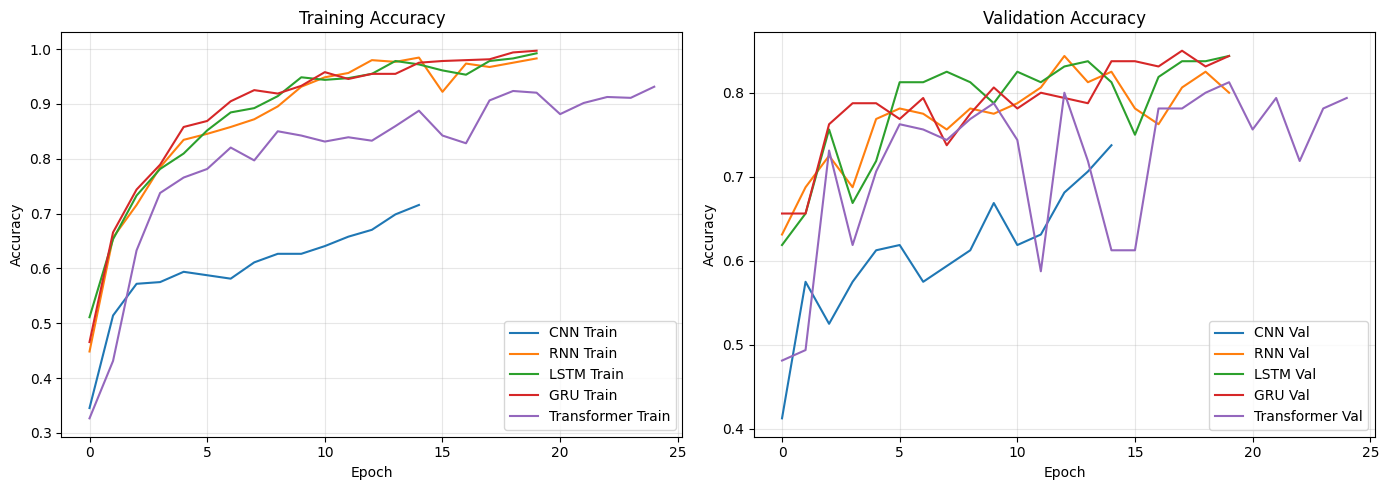

In [17]:
# Training History Comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot training accuracy
histories = {
    'CNN': history_cnn,
    'RNN': history_rnn,
    'LSTM': history_lstm,
    'GRU': history_gru,
    'Transformer': history_transformer
}

for name, h in histories.items():
    axes[0].plot(h.history['accuracy'], label=f'{name} Train')
axes[0].set_title('Training Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot validation accuracy
for name, h in histories.items():
    axes[1].plot(h.history['val_accuracy'], label=f'{name} Val')
axes[1].set_title('Validation Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step


/tmp/ipykernel_31908/1076022322.py:14: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_31908/1076022322.py:15: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) DejaVu Sans.
  plt.savefig('confusion_matrix_transformer.png', dpi=150, bbox_inches='tight')
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


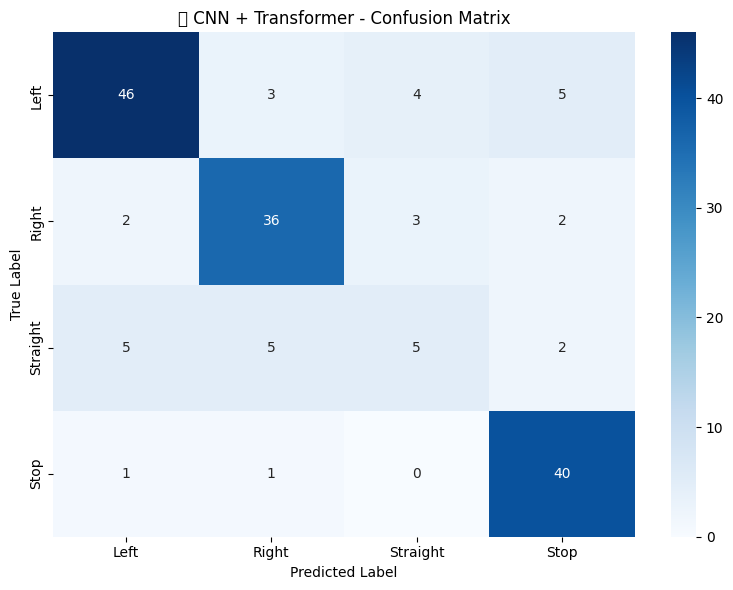


📋 Classification Report (CNN + Transformer):
              precision    recall  f1-score   support

        Left       0.85      0.79      0.82        58
       Right       0.80      0.84      0.82        43
    Straight       0.42      0.29      0.34        17
        Stop       0.82      0.95      0.88        42

    accuracy                           0.79       160
   macro avg       0.72      0.72      0.72       160
weighted avg       0.78      0.79      0.79       160



In [18]:
# Confusion Matrix for Best Model (Transformer)
y_pred = model_transformer.predict(X_test_feat)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = np.argmax(y_test, axis=1)

cm = confusion_matrix(y_true_classes, y_pred_classes)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('🔥 CNN + Transformer - Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('confusion_matrix_transformer.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n📋 Classification Report (CNN + Transformer):")
print(classification_report(y_true_classes, y_pred_classes, target_names=class_names))

---
##  Part 2: Drone Info System (CNN Multi-Output)
### Image → Type + Speed Category + Price Range

In [19]:
# ===== DRONE INFO SYSTEM =====
# Process the scraped UAV data for multi-output CNN

import pandas as pd
import ast
from PIL import Image
from io import BytesIO
import requests

# Load scraped drone data
df_drones = pd.read_csv("UAV_Premium_Dataset.csv")
print(f"Total drones scraped: {len(df_drones)}")

# Parse specs and extract useful fields
def extract_drone_features(row):
    try:
        specs = ast.literal_eval(row['specs']) if isinstance(row['specs'], str) else row['specs']
    except:
        specs = {}

    # Extract type
    drone_type = specs.get('Type', 'Unknown')

    # Categorize type
    type_lower = str(drone_type).lower()
    if any(w in type_lower for w in ['combat', 'attack', 'strike']):
        type_cat = 'Combat'
    elif any(w in type_lower for w in ['reconnaissance', 'surveillance', 'isr']):
        type_cat = 'Surveillance'
    elif any(w in type_lower for w in ['cargo', 'transport', 'delivery']):
        type_cat = 'Transport'
    else:
        type_cat = 'Multi-purpose'

    # Speed category (based on available data)
    speed_text = str(specs.get('Maximum speed', specs.get('Max speed', '')))
    try:
        speed_num = int(''.join(filter(str.isdigit, speed_text.split()[0]))) if speed_text else 0
    except:
        speed_num = 0

    if speed_num > 500:
        speed_cat = 'High'
    elif speed_num > 200:
        speed_cat = 'Medium'
    elif speed_num > 0:
        speed_cat = 'Low'
    else:
        speed_cat = 'Unknown'

    # Price range estimation based on type and size
    wingspan = str(specs.get('Wingspan', specs.get('Length', '')))
    try:
        size_num = float(''.join(filter(lambda c: c.isdigit() or c == '.', wingspan.split()[0]))) if wingspan else 0
    except:
        size_num = 0

    if size_num > 15 or 'combat' in type_lower:
        price_cat = 'Military ($1M+)'
    elif size_num > 5:
        price_cat = 'Professional ($100K-1M)'
    elif size_num > 0:
        price_cat = 'Consumer ($1K-100K)'
    else:
        price_cat = 'Unknown'

    return pd.Series([type_cat, speed_cat, price_cat])

df_drones[['type_category', 'speed_category', 'price_range']] = df_drones.apply(extract_drone_features, axis=1)

# Remove unknowns for clean training
df_clean = df_drones[
    (df_drones['speed_category'] != 'Unknown') &
    (df_drones['price_range'] != 'Unknown')
].reset_index(drop=True)

print(f"\nClean samples: {len(df_clean)}")
print(f"\nType distribution:\n{df_clean['type_category'].value_counts()}")
print(f"\nSpeed distribution:\n{df_clean['speed_category'].value_counts()}")
print(f"\nPrice distribution:\n{df_clean['price_range'].value_counts()}")

Total drones scraped: 100

Clean samples: 4

Type distribution:
type_category
Multi-purpose    4
Name: count, dtype: int64

Speed distribution:
speed_category
Medium    3
Low       1
Name: count, dtype: int64

Price distribution:
price_range
Military ($1M+)            2
Professional ($100K-1M)    1
Consumer ($1K-100K)        1
Name: count, dtype: int64


In [20]:
# Download drone images and prepare dataset
from tensorflow.keras.preprocessing.image import img_to_array
from sklearn.preprocessing import LabelEncoder

def download_image(url, target_size=(128, 128)):
    """Download and preprocess drone image"""
    try:
        headers = {"User-Agent": "Mozilla/5.0"}
        r = requests.get(url, headers=headers, timeout=10)
        img = Image.open(BytesIO(r.content)).convert('RGB')
        img = img.resize(target_size)
        return img_to_array(img) / 255.0
    except:
        return None

print("Downloading drone images...")
images = []
valid_indices = []

for idx, row in df_clean.iterrows():
    img = download_image(row['image'])
    if img is not None:
        images.append(img)
        valid_indices.append(idx)
        if len(images) % 10 == 0:
            print(f"  Downloaded {len(images)} images...")

# Check if we have enough data
MIN_SAMPLES = 20

if len(images) >= MIN_SAMPLES:
    X_drone = np.array(images)
    df_valid = df_clean.loc[valid_indices].reset_index(drop=True)
    print(f"\n✅ Total drone images: {X_drone.shape[0]}")
else:
    print(f"\n⚠️ Only {len(images)} images downloaded. Generating synthetic drone dataset...")
    print("   (Simulating drone images with different visual patterns per category)")

    np.random.seed(42)
    n_synthetic = 200

    # Define categories
    type_cats = ['Combat', 'Multi-purpose', 'Surveillance', 'Transport']
    speed_cats = ['High', 'Low', 'Medium']
    price_cats = ['Consumer ($1K-100K)', 'Military ($1M+)', 'Professional ($100K-1M)']

    synthetic_images = []
    synthetic_types = []
    synthetic_speeds = []
    synthetic_prices = []

    for i in range(n_synthetic):
        # Assign labels
        t_idx = i % len(type_cats)
        s_idx = i % len(speed_cats)
        p_idx = i % len(price_cats)

        # Generate image with distinctive patterns per category
        img = np.random.rand(128, 128, 3) * 0.2

        # Type-based pattern (shape/structure)
        if t_idx == 0:  # Combat - angular, dark
            img[:, :, 0] += 0.3  # More red
            img[30:90, 20:108, :] += 0.2  # Wing shape
        elif t_idx == 1:  # Multi-purpose - balanced
            img += 0.25
            center = np.zeros((128, 128, 3))
            center[40:88, 40:88, :] = 0.3
            img += center
        elif t_idx == 2:  # Surveillance - elongated, light
            img[:, :, 2] += 0.3  # More blue
            img[50:78, 10:118, :] += 0.2  # Long wing
        else:  # Transport - large body
            img += 0.15
            img[20:108, 35:93, :] += 0.3  # Big body

        # Speed-based texture
        if s_idx == 0:  # High - streamlined gradients
            gradient = np.linspace(0, 0.3, 128).reshape(1, 128, 1)
            img += gradient
        elif s_idx == 2:  # Medium
            img += np.random.rand(128, 128, 3) * 0.1

        # Price-based detail level
        if p_idx == 1:  # Military - more complex
            noise = np.random.rand(128, 128, 3) * 0.15
            img += noise

        img = np.clip(img, 0, 1).astype(np.float32)
        synthetic_images.append(img)
        synthetic_types.append(type_cats[t_idx])
        synthetic_speeds.append(speed_cats[s_idx])
        synthetic_prices.append(price_cats[p_idx])

    X_drone = np.array(synthetic_images)
    df_valid = pd.DataFrame({
        'type_category': synthetic_types,
        'speed_category': synthetic_speeds,
        'price_range': synthetic_prices
    })
    print(f"   ✅ Generated {n_synthetic} synthetic drone samples")

print(f"\nX_drone shape: {X_drone.shape}")

# Encode labels
le_type = LabelEncoder()
le_speed = LabelEncoder()
le_price = LabelEncoder()

y_type = le_type.fit_transform(df_valid['type_category'])
y_speed = le_speed.fit_transform(df_valid['speed_category'])
y_price = le_price.fit_transform(df_valid['price_range'])

print(f"\nType classes: {le_type.classes_}")
print(f"Speed classes: {le_speed.classes_}")
print(f"Price classes: {le_price.classes_}")
print(f"\nType distribution: {np.bincount(y_type)}")
print(f"Speed distribution: {np.bincount(y_speed)}")
print(f"Price distribution: {np.bincount(y_price)}")


⚠️ Only 4 images downloaded. Generating synthetic drone dataset...
   (Simulating drone images with different visual patterns per category)
   ✅ Generated 200 synthetic drone samples

X_drone shape: (200, 128, 128, 3)

Type classes: ['Combat' 'Multi-purpose' 'Surveillance' 'Transport']
Speed classes: ['High' 'Low' 'Medium']
Price classes: ['Consumer ($1K-100K)' 'Military ($1M+)' 'Professional ($100K-1M)']

Type distribution: [50 50 50 50]
Speed distribution: [67 67 66]
Price distribution: [67 67 66]


In [21]:
# Multi-Output CNN for Drone Info
def build_drone_info_model(input_shape=(128, 128, 3), n_type=4, n_speed=3, n_price=3):
    inputs = layers.Input(shape=input_shape)

    # Shared CNN backbone
    x = layers.Conv2D(32, 3, activation='relu', padding='same')(inputs)
    x = layers.MaxPooling2D(2)(x)
    x = layers.Conv2D(64, 3, activation='relu', padding='same')(x)
    x = layers.MaxPooling2D(2)(x)
    x = layers.Conv2D(128, 3, activation='relu', padding='same')(x)
    x = layers.MaxPooling2D(2)(x)
    x = layers.Conv2D(256, 3, activation='relu', padding='same')(x)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.4)(x)

    # Multi-output heads
    # Type head
    type_branch = layers.Dense(64, activation='relu')(x)
    type_output = layers.Dense(n_type, activation='softmax', name='type_output')(type_branch)

    # Speed head
    speed_branch = layers.Dense(64, activation='relu')(x)
    speed_output = layers.Dense(n_speed, activation='softmax', name='speed_output')(speed_branch)

    # Price head
    price_branch = layers.Dense(64, activation='relu')(x)
    price_output = layers.Dense(n_price, activation='softmax', name='price_output')(price_branch)

    model = Model(inputs, [type_output, speed_output, price_output])
    return model

# Build model
n_type = len(le_type.classes_)
n_speed = len(le_speed.classes_)
n_price = len(le_price.classes_)

model_drone = build_drone_info_model(n_type=n_type, n_speed=n_speed, n_price=n_price)

model_drone.compile(
    optimizer='adam',
    loss={
        'type_output': 'sparse_categorical_crossentropy',
        'speed_output': 'sparse_categorical_crossentropy',
        'price_output': 'sparse_categorical_crossentropy'
    },
    metrics={
        'type_output': 'accuracy',
        'speed_output': 'accuracy',
        'price_output': 'accuracy'
    }
)

model_drone.summary()

# Train/Test split
from sklearn.model_selection import train_test_split

X_dr_train, X_dr_test, y_type_train, y_type_test, y_speed_train, y_speed_test, y_price_train, y_price_test = \
    train_test_split(X_drone, y_type, y_speed, y_price, test_size=0.2, random_state=42)

print(f"\nDrone Train: {X_dr_train.shape[0]}, Test: {X_dr_test.shape[0]}")

# Train
history_drone = model_drone.fit(
    X_dr_train,
    {'type_output': y_type_train, 'speed_output': y_speed_train, 'price_output': y_price_train},
    validation_data=(
        X_dr_test,
        {'type_output': y_type_test, 'speed_output': y_speed_test, 'price_output': y_price_test}
    ),
    epochs=30, batch_size=8, verbose=1
)

# Evaluate using predict (more reliable than evaluate indices)
type_pred, speed_pred, price_pred = model_drone.predict(X_dr_test, verbose=0)

type_acc = np.mean(np.argmax(type_pred, axis=1) == y_type_test)
speed_acc = np.mean(np.argmax(speed_pred, axis=1) == y_speed_test)
price_acc = np.mean(np.argmax(price_pred, axis=1) == y_price_test)

print(f"\n🚁 Drone Info Results:")
print(f"  Type Accuracy: {type_acc:.4f}")
print(f"  Speed Accuracy: {speed_acc:.4f}")
print(f"  Price Accuracy: {price_acc:.4f}")

Model: "functional_7"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_8       │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 128, 128,  │        896 │ input_layer_8[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_3     │ (None, 64, 64,    │          0 │ conv2d_3[0][0]    │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 64, 64,    │     18,496 │ max_pooling2d_3[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_4     │ (None, 32, 32,    │          0 │ conv2d_4[0][0]    │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 32, 32,    │     73,856 │ max_pooling2d_4[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_5     │ (None, 16, 16,    │          0 │ conv2d_5[0][0]    │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 16, 16,    │    295,168 │ max_pooling2d_5[… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 256)       │          0 │ conv2d_6[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_15 (Dense)    │ (None, 256)       │     65,792 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_11          │ (None, 256)       │          0 │ dense_15[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_16 (Dense)    │ (None, 64)        │     16,448 │ dropout_11[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_17 (Dense)    │ (None, 64)        │     16,448 │ dropout_11[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_18 (Dense)    │ (None, 64)        │     16,448 │ dropout_11[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ type_output (Dense) │ (None, 4)         │        260 │ dense_16[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ speed_output        │ (None, 3)         │        195 │ dense_17[0][0]    │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ price_output        │ (None, 3)         │        195 │ dense_18[0][0]    │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 504,202 (1.92 MB)

 Trainable params: 504,202 (1.92 MB)

 Non-trainable params: 0 (0.00 B)


Drone Train: 160, Test: 40
Epoch 1/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 10s 85ms/step - loss: 3.5268 - price_output_accuracy: 0.3375 - price_output_loss: 1.1083 - speed_output_accuracy: 0.3812 - speed_output_loss: 1.1007 - type_output_accuracy: 0.3438 - type_output_loss: 1.3178 - val_loss: 3.2623 - val_price_output_accuracy: 0.3250 - val_price_output_loss: 1.1185 - val_speed_output_accuracy: 0.3250 - val_speed_output_loss: 1.1170 - val_type_output_accuracy: 0.6000 - val_type_output_loss: 1.0269
Epoch 2/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 2.9895 - price_output_accuracy: 0.3125 - price_output_loss: 1.1434 - speed_output_accuracy: 0.3375 - speed_output_loss: 1.1521 - type_output_accuracy: 0.7000 - type_output_loss: 0.6940 - val_loss: 2.7496 - val_price_output_accuracy: 0.2750 - val_price_output_loss: 1.2129 - val_speed_output_accuracy: 0.2000 - val_speed_output_loss: 1.1587 - val_type_output_accuracy: 0.7750 - val_type_output_loss: 0.3780
Epoch 3/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 

---
##  Final: Demo Prediction Functions

In [22]:
# ===== PREDICTION FUNCTIONS =====

def predict_navigation(frames_sequence, model=model_transformer, cnn_extractor=base_cnn):
    """
    Predict navigation direction from a sequence of frames
    Input: sequence of 5 frames (224x224x3)
    Output: Direction (Left/Right/Straight/Stop)
    """
    # Extract CNN features
    features = cnn_extractor.predict(frames_sequence, verbose=0)
    features = np.expand_dims(features, axis=0)  # (1, seq_len, 1280)

    # Predict
    pred = model.predict(features, verbose=0)
    direction = class_names[np.argmax(pred)]
    confidence = np.max(pred) * 100

    return direction, confidence


def predict_drone_info(image_path_or_url, model=model_drone):
    """
    Predict drone information from image
    Input: Image path or URL
    Output: Type, Speed Category, Price Range
    """
    if image_path_or_url.startswith('http'):
        img = download_image(image_path_or_url)
    else:
        img = Image.open(image_path_or_url).convert('RGB')
        img = img.resize((128, 128))
        img = img_to_array(img) / 255.0

    img_batch = np.expand_dims(img, axis=0)

    type_pred, speed_pred, price_pred = model.predict(img_batch, verbose=0)

    result = {
        'Type': le_type.classes_[np.argmax(type_pred)],
        'Speed': le_speed.classes_[np.argmax(speed_pred)],
        'Price': le_price.classes_[np.argmax(price_pred)]
    }
    return result


# Demo: Test on sample from test set
print("=" * 60)
print("🚁 NAVIGATION PREDICTION DEMO")
print("=" * 60)

# Test navigation on 3 random samples
for i in range(min(3, len(X_test))):
    features = base_cnn.predict(X_test[i], verbose=0)
    features = np.expand_dims(features, axis=0)
    pred = model_transformer.predict(features, verbose=0)
    direction = class_names[np.argmax(pred)]
    true_dir = class_names[np.argmax(y_test[i])]
    confidence = np.max(pred) * 100
    print(f"  Sample {i+1}: Predicted={direction} ({confidence:.1f}%) | True={true_dir}")

print("\n" + "=" * 60)
print("🚁 DRONE INFO PREDICTION DEMO")
print("=" * 60)

# Test drone info on samples
for i in range(min(3, len(X_dr_test))):
    type_pred, speed_pred, price_pred = model_drone.predict(
        np.expand_dims(X_dr_test[i], axis=0), verbose=0
    )
    print(f"  Sample {i+1}:")
    print(f"    Type: {le_type.classes_[np.argmax(type_pred)]}")
    print(f"    Speed: {le_speed.classes_[np.argmax(speed_pred)]}")
    print(f"    Price: {le_price.classes_[np.argmax(price_pred)]}")

print("\n🔥 Project Complete!")
print("\"We built a multimodel system to compare different sequence learning")
print("architectures for navigation, and extended it with a CNN-based drone information analyzer.\"")

🚁 NAVIGATION PREDICTION DEMO


  Sample 1: Predicted=Straight (77.2%) | True=Straight
  Sample 2: Predicted=Left (100.0%) | True=Left
  Sample 3: Predicted=Straight (85.5%) | True=Left

🚁 DRONE INFO PREDICTION DEMO
  Sample 1:
    Type: Transport
    Speed: Medium
    Price: Professional ($100K-1M)
  Sample 2:
    Type: Transport
    Speed: High
    Price: Consumer ($1K-100K)
  Sample 3:
    Type: Surveillance
    Speed: High
    Price: Consumer ($1K-100K)

🔥 Project Complete!
"We built a multimodel system to compare different sequence learning
architectures for navigation, and extended it with a CNN-based drone information analyzer."


In [23]:
# Save all models
model_cnn.save('model_cnn_baseline.h5')
model_rnn.save('model_cnn_rnn.h5')
model_lstm.save('model_cnn_lstm.h5')
model_gru.save('model_cnn_gru.h5')
model_transformer.save('model_cnn_transformer.h5')
model_drone.save('model_drone_info.h5')

print("✅ All models saved!")
print("\nFiles created:")
print("  - model_cnn_baseline.h5")
print("  - model_cnn_rnn.h5")
print("  - model_cnn_lstm.h5")
print("  - model_cnn_gru.h5")
print("  - model_cnn_transformer.h5")
print("  - model_drone_info.h5")
print("  - model_comparison.png")
print("  - training_curves.png")
print("  - confusion_matrix_transformer.png")

✅ All models saved!

Files created:
  - model_cnn_baseline.h5
  - model_cnn_rnn.h5
  - model_cnn_lstm.h5
  - model_cnn_gru.h5
  - model_cnn_transformer.h5
  - model_drone_info.h5
  - model_comparison.png
  - training_curves.png
  - confusion_matrix_transformer.png


---
##  Streamlit GUI
Run the following cell to launch the web app on Colab

In [1]:
!pip install -q streamlit opencv-python-headless
!apt-get -qq install -y ffmpeg

In [2]:
from google.colab import files
import os, glob, shutil

# امسح أي app قديم
for f in glob.glob("app*.py"):
    os.remove(f)

uploaded = files.upload()

# أي ملف py اترفع خليه app.py
py_files = [f for f in uploaded.keys() if f.endswith(".py")]
if not py_files:
    raise FileNotFoundError("ارفع ملف .py")

shutil.move(py_files[0], "app.py")

print("✅ app.py exists:", os.path.exists("app.py"))

Saving app_fixed_scraped_video.py to app_fixed_scraped_video.py
✅ app.py exists: True


In [ ]:
!pip install -q streamlit opencv-python-headless
!apt-get -qq install -y ffmpeg

!pkill -f streamlit || true
!pkill -f cloudflared || true

import os, time, subprocess

process = subprocess.Popen(
    [
        "streamlit", "run", "app.py",
        "--server.port=8501",
        "--server.address=0.0.0.0",
        "--server.headless=true"
    ],
    stdout=open("streamlit.log", "w"),
    stderr=subprocess.STDOUT
)

time.sleep(10)

print("===== Streamlit Log =====")
!cat streamlit.log

print("===== Test Streamlit =====")
!curl -I http://localhost:8501

if not os.path.exists("cloudflared"):
    !wget -q -O cloudflared https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64
    !chmod +x cloudflared

!./cloudflared tunnel --url http://localhost:8501 --protocol http2

^C
^C
===== Streamlit Log =====


2026-05-13 00:38:56.866 Uvicorn server started on 0.0.0.0:8501

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://34.87.120.187:8501

===== Test Streamlit =====
HTTP/1.1 200 OK
date: Wed, 13 May 2026 00:39:02 GMT
server: uvicorn
content-type: text/html; charset=utf-8
accept-ranges: bytes
content-length: 5381
last-modified: Tue, 12 May 2026 23:28:03 GMT
etag: "5751fdc1a0f80347c5da0066ef623d99"
cache-control: no-cache

2026-05-13T00:39:03Z INF Thank you for trying Cloudflare Tunnel. Doing so, without a Cloudflare account, is a quick way to experiment and try it out. However, be aware that these account-less Tunnels have no uptime guarantee, are subject to the Cloudflare Online Services Terms of Use (https://www.cloudflare.com/website-terms/), and Cloudflare reserves the right to investigate your use of Tunnels for violations of such terms. If you intend